## Part 1

In [19]:
!python3 -c "import pyspark; print(pyspark.__version__)"

4.1.1


## Part 2

In [6]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC Taxi Analytics Assignment")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

In [14]:
green_path = "data/green_tripdata_2026-01.parquet"
yellow_path = "data/yellow_tripdata_2026-01.parquet"

In [15]:
green_df = spark.read.parquet(green_path)
yellow_df = spark.read.parquet(yellow_path)

## Part 3  

In [18]:
yellow_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [16]:
green_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- lpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- lpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- trip_type: long (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [20]:
yellow_df.show(5, truncate=False)
green_df.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

## Part 4

In [21]:
from pyspark.sql import functions as F

shared_cols = [
    "taxi_type",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
]

yellow_std = (
    yellow_df
    .withColumnRenamed("tpep_pickup_datetime", "pickup_datetime")
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")
    .withColumn("taxi_type", F.lit("yellow"))
    .select(*shared_cols)
)

green_std = (
    green_df
    .withColumnRenamed("lpep_pickup_datetime", "pickup_datetime")
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")
    .withColumn("taxi_type", F.lit("green"))
    .select(*shared_cols)
)

trips_df = yellow_std.unionByName(green_std)
trips_df.printSchema()

root
 |-- taxi_type: string (nullable = false)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: long (nullable = true)



In [34]:
trips_df.show(5)

+---------+-------------------+-------------------+------------+------------+---------------+-------------+-----------+------------+------------+
|taxi_type|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|passenger_count|trip_distance|fare_amount|total_amount|payment_type|
+---------+-------------------+-------------------+------------+------------+---------------+-------------+-----------+------------+------------+
|   yellow|2026-01-01 00:54:04|2026-01-01 00:59:37|         239|         238|              1|         0.97|        7.2|       15.86|           1|
|   yellow|2026-01-01 00:34:04|2026-01-01 00:39:47|         163|         162|              0|          0.9|        7.9|       13.65|           2|
|   yellow|2026-01-01 00:57:06|2026-01-01 01:05:59|          43|         237|              0|          1.4|       10.7|       18.95|           1|
|   yellow|2026-01-01 00:15:22|2026-01-01 00:58:10|         142|         209|              4|         5.58|       38.7|     

## Part 5

In [23]:
trip_duration_sec = F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")

trips_clean = (
    trips_df
    .filter(F.col("pickup_datetime").isNotNull())
    .filter(F.col("dropoff_datetime").isNotNull())
    .filter(F.col("trip_distance") > 0)
    .filter(F.col("fare_amount") >= 0)
    .filter(F.col("total_amount") >= 0)
    .filter(F.col("dropoff_datetime") >= F.col("pickup_datetime"))
    .filter(trip_duration_sec <= 24 * 60 * 60)
)

In [24]:
before = trips_df.count()
after = trips_clean.count()
print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before - after:,} ({(before - after) / before:.2%})")

Rows before cleaning: 3,765,161
Rows after cleaning:  3,600,946
Rows removed:         164,215 (4.36%)


## Part 6

### Question 1: which taxi type had more trips?

In [25]:
trips_by_type = (
    trips_clean.groupBy("taxi_type")
    .count()
    .orderBy(F.col("count").desc())
)
trips_by_type.show()

winner = trips_by_type.first()
print(f"Answer: {winner['taxi_type']} had more trips ({winner['count']:,}).")

+---------+-------+
|taxi_type|  count|
+---------+-------+
|   yellow|3562033|
|    green|  38913|
+---------+-------+

Answer: yellow had more trips (3,562,033).


### Question 2: What hour of day had the most pickups?

In [26]:
pickups_by_hour = (
    trips_clean
    .withColumn("pickup_hour", F.hour("pickup_datetime"))
    .groupBy("pickup_hour")
    .count()
    .orderBy(F.col("count").desc())
)
pickups_by_hour.show(24)

top_hour = pickups_by_hour.first()
print(f"Answer: hour {top_hour['pickup_hour']:02d}:00 had the most pickups ({top_hour['count']:,}).")

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         18|235765|
|         17|227332|
|         15|219306|
|         19|213794|
|         20|210273|
|         21|209653|
|         16|209371|
|         14|205223|
|         13|193716|
|         22|192096|
|         12|185623|
|         11|170266|
|         10|160406|
|          9|156308|
|         23|150074|
|          8|148023|
|          7|113377|
|          0|109932|
|          1| 76311|
|          6| 63194|
|          2| 52923|
|          3| 37781|
|          5| 32233|
|          4| 27966|
+-----------+------+

Answer: hour 18:00 had the most pickups (235,765).


### Question 3: what percentage of trips were under 2 miles?

In [27]:
stats = trips_clean.agg(
    F.count("*").alias("total"),
    F.sum(F.when(F.col("trip_distance") < 2, 1).otherwise(0)).alias("under_2mi"),
).first()

pct_under_2 = stats["under_2mi"] / stats["total"] * 100
print(f"Answer: {pct_under_2:.2f}% of trips were under 2 miles ({stats['under_2mi']:,} of {stats['total']:,}).")

Answer: 52.12% of trips were under 2 miles (1,876,798 of 3,600,946).


### Question 4: What is the average trip distance by taxi type?

In [28]:
avg_dist = (
    trips_clean.groupBy("taxi_type")
    .agg(F.round(F.avg("trip_distance"), 3).alias("avg_trip_distance_mi"))
    .orderBy("taxi_type")
)
avg_dist.show()

+---------+--------------------+
|taxi_type|avg_trip_distance_mi|
+---------+--------------------+
|    green|              12.989|
|   yellow|               6.705|
+---------+--------------------+



### Question 5: Predict fare amount

In [29]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

model_df = (
    trips_clean
    .withColumn("pickup_hour", F.hour("pickup_datetime"))
    .withColumn("pickup_dow", F.dayofweek("pickup_datetime"))
    .withColumn(
        "trip_duration_min",
        (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")) / 60.0,
    )
    .na.drop(subset=["passenger_count", "payment_type", "PULocationID", "DOLocationID"])
)

In [35]:
numeric_features = [
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "pickup_hour",
    "pickup_dow",
]
categorical_features = ["taxi_type", "payment_type"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_features
]
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_features],
    outputCols=[f"{c}_ohe" for c in categorical_features],
)
assembler = VectorAssembler(
    inputCols=numeric_features + [f"{c}_ohe" for c in categorical_features],
    outputCol="features",
)

In [36]:
lr = LinearRegression(featuresCol="features", labelCol="fare_amount")

pipeline = Pipeline(stages=indexers + [encoder, assembler, lr])

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train rows: {train_df.count():,}")
print(f"Test rows:  {test_df.count():,}")

Train rows: 2,080,219
Test rows:  520,062


In [37]:
model = pipeline.fit(train_df)

evaluator = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="rmse"
)

train_rmse = evaluator.evaluate(model.transform(train_df))
test_rmse = evaluator.evaluate(model.transform(test_df))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing  RMSE: {test_rmse:.4f}")

Training RMSE: 16.5811
Testing  RMSE: 16.6008


In [38]:
lr_model = model.stages[-1]
feature_names = (
    numeric_features
    + [f"taxi_type_ohe[{i}]" for i in range(lr_model.numFeatures - len(numeric_features))]
)

coefs = list(zip(feature_names, lr_model.coefficients.toArray()))
coefs.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"Intercept: {lr_model.intercept:.4f}\n")
print("Coefficients (sorted by |magnitude|):")
for name, c in coefs:
    print(f"  {name:>30s}  {c:+.4f}")

Intercept: 13.2877

Coefficients (sorted by |magnitude|):
                taxi_type_ohe[4]  +3.9530
                taxi_type_ohe[1]  -1.4596
                taxi_type_ohe[0]  +1.4596
                 passenger_count  +1.3533
                taxi_type_ohe[5]  +1.0096
                taxi_type_ohe[2]  -0.3881
                      pickup_dow  -0.2763
               trip_duration_min  +0.2704
                taxi_type_ohe[3]  -0.0124
                   trip_distance  +0.0117
                     pickup_hour  -0.0116


Feature Importance Analysis: 
- The largest magnitude coefficients are the one hot encoded features which are the combinations of taxi type (2) and payment type (3), leading to 5 different features (only 5 since dropLast = True). These coefficient differences may account for different pricing based on the vechile and potentially an extra fee for paying with credit card instead of cash.
- Trip distance has a coefficient on only 0.0117, which is much smaller than what we would expect driving around NYC. This is likely due to the multicolinearity with trip duration min with coefficient 0.2704. Distance and duration are highly correlated, so the regression splits the signal between the two features in way that is not causal / matching the true underlying behavior.
- The coefficient for passenger count is larger than expected. From intuition, we know that a taxi traveling a fixed distance charges the same amount, independent of the number of people riding in the taxi. The reason for the higher coefficient may be that rides with more passengers tend to be groups that are traveling farther distance, e.g. going to the airport.
- Pickup day of the week and pickup hour contribute small amounts. The standard day and hour encoding is a weak signal with a negligible affect on fare amount.


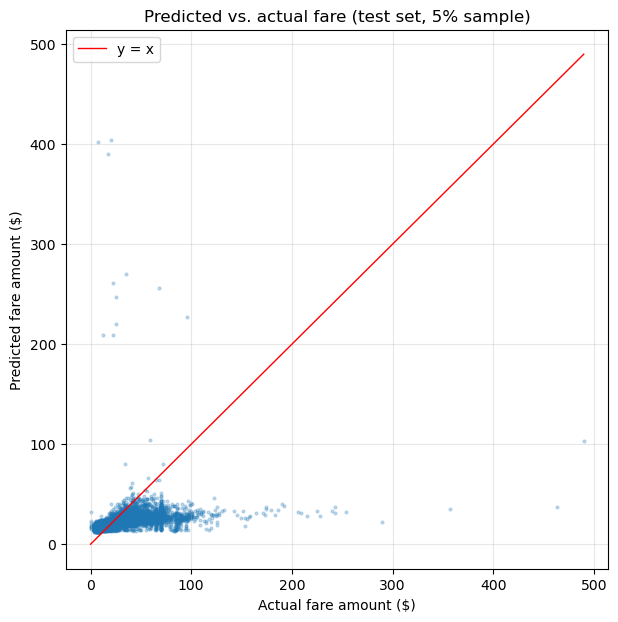

In [50]:
import matplotlib.pyplot as plt
import numpy as np

preds_pd = (
    model.transform(test_df)
    .select("fare_amount", "prediction")
    .sample(fraction=0.05, seed=42)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(preds_pd["fare_amount"], preds_pd["prediction"], s=4, alpha=0.25)

lo = float(min(preds_pd["fare_amount"].min(), preds_pd["prediction"].min()))
hi = float(max(preds_pd["fare_amount"].max(), preds_pd["prediction"].max()))
ax.plot([lo, hi], [lo, hi], color="red", linewidth=1, label="y = x")

ax.set_xlabel("Actual fare amount ($)")
ax.set_ylabel("Predicted fare amount ($)")
ax.set_title("Predicted vs. actual fare (test set, 5% sample)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

fig.savefig('nyc-taxi-assignment/predicted_vs_actual.png', dpi=300)

## Part 7

In [48]:
from pyspark.sql import Row

pct_under_2_df = spark.createDataFrame([
    Row(metric="pct_under_2_miles", value=float(pct_under_2))
])

In [51]:
local_base = "/home/jovyan/work/nyc-taxi-assignment"

# q1
trips_by_type.write.mode("overwrite").parquet(f"{local_base}/trips_by_type")
# q2
pickups_by_hour.write.mode("overwrite").parquet(f"{local_base}/pickups_by_hour")
# q3
pct_under_2_df.write.mode("overwrite").parquet(f"{local_base}/pct_under_2")
# q4
avg_dist.write.mode("overwrite").parquet(f"{local_base}/avg_dist")
#q5
fig.savefig('nyc-taxi-assignment/predicted_vs_actual.png', dpi=300)

In [54]:
!aws s3 cp --recursive /home/jovyan/work/nyc-taxi-assignment s3://barnett-evan-lab3/nyc-taxi-assignment

upload: nyc-taxi-assignment/avg_dist/.part-00000-af0cbd97-4245-4a06-83c9-f8394bc7766c-c000.snappy.parquet.crc to s3://barnett-evan-lab3/nyc-taxi-assignment/avg_dist/.part-00000-af0cbd97-4245-4a06-83c9-f8394bc7766c-c000.snappy.parquet.crc
upload: nyc-taxi-assignment/pickups_by_hour/._SUCCESS.crc to s3://barnett-evan-lab3/nyc-taxi-assignment/pickups_by_hour/._SUCCESS.crc
upload: nyc-taxi-assignment/pct_under_2/_SUCCESS to s3://barnett-evan-lab3/nyc-taxi-assignment/pct_under_2/_SUCCESS
upload: nyc-taxi-assignment/pct_under_2/.part-00000-d4857c34-0b77-4994-b94d-d9063d489686-c000.snappy.parquet.crc to s3://barnett-evan-lab3/nyc-taxi-assignment/pct_under_2/.part-00000-d4857c34-0b77-4994-b94d-d9063d489686-c000.snappy.parquet.crc
upload: nyc-taxi-assignment/avg_dist/_SUCCESS to s3://barnett-evan-lab3/nyc-taxi-assignment/avg_dist/_SUCCESS
upload: nyc-taxi-assignment/pct_under_2/._SUCCESS.crc to s3://barnett-evan-lab3/nyc-taxi-assignment/pct_under_2/._SUCCESS.crc
upload: nyc-taxi-assignment/avg_